#### **Introduction:** In this analytical venture, we explore a compelling dataset focused on demographic and work-related factors to predict individual income levels. Our journey takes us through comprehensive data analysis, preprocessing techniques, and predictive modeling, aiming to construct a model that accurately forecasts whether an individual earns more than $50K annually. This project stands as a testament to the practical application of data science methodologies and machine learning's predictive prowess.

#### **Data Loading and Exploration:** Our first stride in this analytical journey was to load the data using Pandas' read_csv function, providing us with a foundational understanding of our dataset's structure. Initial exploration involved scrutinizing our data's head and employing the describe function to grasp our data's statistical summary. We unearthed essential insights using Seaborn to generate visualizations such as boxplot and countplot, which illuminated data distributions, potential outliers, and the categorical variables' behavior. This phase was crucial in setting the stage for subsequent data manipulation and modeling.

#### Problem: Identifying socioeconomic and occupational factors that influence an individual's
#### likelihood of earning above $50K, to inform targeted interventions, policies, or business
#### strategies

#### Business requirments:
#### Demographics Analysis: Understand the distribution of icome across different demographics (gender, race, & education).
#### Occupation and income: Identify which occupation tends to have a higher likelihood of earning above 50K.
#### Working Hours Analysis: Determine if there's a correlation between the number of hours worked per week and earning above 50K.
#### Capital Gains and Losses Impact: Analyze if individuals with higher capital gains or losses have a higher likelihood of earning more than 50K.

#### **Data Preprocessing:** Faced with challenges such as missing values and categorical variables, we approached data preprocessing with meticulous care. Utilizing functions like fillna for imputing missing data and get_dummies for one-hot encoding categorical features, we ensured our dataset's readiness for machine learning algorithms. The preprocessing stage fortified our dataset, transforming it into an ideal candidate for further analysis and modeling, thus bridging the gap between raw data and actionable insights.

#### **Conclusion:** We looked at what affects people's earnings and found that jobs and education matter a lot in making more than $50K a year. Our computer program could guess pretty well but wasn't perfect,so we need to try other ways to make it smarter. This work showed how different life factors create pay differences and hints at big decisions for making things fairer. Going forward, we need to use more types of information and maybe new methods to understand the whole picture better.

In [1]:
# data manipulation libraries
import pandas as pd
import numpy as np

# visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# remove warnings
import warnings
warnings.filterwarnings("ignore")

# StandardScaler
from sklearn.preprocessing import StandardScaler

# data balance
from imblearn.over_sampling import SMOTE

# LabelEncoder
from sklearn.preprocessing import LabelEncoder

# data split
from sklearn.model_selection import train_test_split

# model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Accuracy
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Save model
import pickle

## Data Set Information

### read csv file

In [3]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('Train.csv')
df.head(5)

,ID,age,gender,education,class,education_institute,marital_status,race,is_hispanic,employment_commitment,unemployment_reason,employment_stat,wage_per_hour,is_labor_union,working_week_per_year,industry_code,industry_code_main,occupation_code,occupation_code_main,total_employed,household_stat,household_summary,under_18_family,veterans_admin_questionnaire,vet_benefit,tax_status,gains,losses,stocks_status,citizenship,mig_year,country_of_birth_own,country_of_birth_father,country_of_birth_mother,migration_code_change_in_msa,migration_prev_sunbelt,migration_code_move_within_reg,migration_code_change_in_reg,residence_1_year_ago,old_residence_reg,old_residence_state,importance_of_record,income_above_limit
0,ID_TZ0000,79,Female,High school graduate,NaN,NaN,Widowed,White,All other,Not in labor force,NaN,0,0,NaN,52,0,Not in universe or children,0,NaN,2,Householder,Householder,NaN,NaN,2,Head of household,0,0,292,Native,95,US,US,US,?,?,?,?,NaN,NaN,NaN,1779.74,Below limit
1,ID_TZ0001,65,Female,High school graduate,NaN,NaN,Widowed,White,All other,Children or Armed Forces,NaN,0,0,NaN,0,0,Not in universe or children,0,NaN,0,Nonfamily householder,Householder,NaN,NaN,2,Single,0,0,0,Native,94,US,US,US,unchanged,NaN,unchanged,unchanged,Same,NaN,NaN,2366.75,Below limit
2,ID_TZ0002,21,Male,12th grade no diploma,Federal government,NaN,Never married,Black,All other,Children or Armed Forces,NaN,0,500,No,15,41,Hospital services,26,Adm support including clerical,4,Child 18+ never marr Not in a subfamily,Child 18 or older,NaN,NaN,2,Single,0,0,0,Native,94,US,US,US,unchanged,NaN,unchanged,unchanged,Same,NaN,NaN,1693.42,Below limit
3,ID_TZ0003,2,Female,Children,NaN,NaN,Never married,Asian or Pacific Islander,All other,Children or Armed Forces,NaN,0,0,NaN,0,0,Not in universe or children,0,NaN,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,NaN,0,Nonfiler,0,0,0,Native,94,US,India,India,unchanged,NaN,unchanged,unchanged,Same,NaN,NaN,1380.27,Below limit
4,ID_TZ0004,70,Male,High school graduate,NaN,NaN,Married-civilian spouse present,White,All other,Not in labor force,NaN,0,0,NaN,0,0,Not in universe or children,0,NaN,0,Spouse of householder,Spouse of householder,NaN,NaN,2,Joint both 65+,0,0,0,Native,95,US,US,US,?,?,?,?,NaN,NaN,NaN,1580.79,Below limit


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209499 entries, 0 to 209498
Data columns (total 43 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              209499 non-null  str    
 1   age                             209499 non-null  int64  
 2   gender                          209499 non-null  str    
 3   education                       209499 non-null  str    
 4   class                           104254 non-null  str    
 5   education_institute             13302 non-null   str    
 6   marital_status                  209499 non-null  str    
 7   race                            209499 non-null  str    
 8   is_hispanic                     209499 non-null  str    
 9   employment_commitment           209499 non-null  str    
 10  unemployment_reason             6520 non-null    str    
 11  employment_stat                 209499 non-null  int64  
 12  wage_per_hour              

In [5]:
df.describe()

,age,employment_stat,wage_per_hour,working_week_per_year,industry_code,occupation_code,total_employed,vet_benefit,gains,losses,stocks_status,mig_year,importance_of_record
count,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000,209499.000000
mean,34.518728,0.176760,55.433487,23.158850,15.332398,11.321734,1.956067,1.515854,435.926887,36.881737,194.533420,94.499745,1740.888324
std,22.306738,0.555562,276.757327,24.397963,18.049655,14.460839,2.365154,0.850853,4696.359500,270.383302,1956.375501,0.500001,995.559557
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000,37.870000
25%,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,94.000000,1061.290000
50%,33.000000,0.000000,0.000000,8.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,94.000000,1617.040000
75%,50.000000,0.000000,0.000000,52.000000,33.000000,26.000000,4.000000,2.000000,0.000000,0.000000,0.000000,95.000000,2185.480000
max,90.000000,2.000000,9999.000000,52.000000,51.000000,46.000000,6.000000,2.000000,99999.000000,4608.000000,99999.000000,95.000000,18656.300000


## Data Cleaning

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['ID', 'age', 'gender', 'education', 'class', 'education_institute',
       'marital_status', 'race', 'is_hispanic', 'employment_commitment',
       'unemployment_reason', 'employment_stat', 'wage_per_hour',
       'is_labor_union', 'working_week_per_year', 'industry_code',
       'industry_code_main', 'occupation_code', 'occupation_code_main',
       'total_employed', 'household_stat', 'household_summary',
       'under_18_family', 'veterans_admin_questionnaire', 'vet_benefit',
       'tax_status', 'gains', 'losses', 'stocks_status', 'citizenship',
       'mig_year', 'country_of_birth_own', 'country_of_birth_father',
       'country_of_birth_mother', 'migration_code_change_in_msa',
       'migration_prev_sunbelt', 'migration_code_move_within_reg',
       'migration_code_change_in_reg', 'residence_1_year_ago',
       'old_residence_reg', 'old_residence_state', 'importance_of_record',
       'income_above_limit'],
      dtype='str')

In [8]:
df.drop(['race','is_labor_union','country_of_birth_father','veterans_admin_questionnaire','old_residence_state','country_of_birth_mother','migration_code_change_in_msa','migration_prev_sunbelt','migration_code_move_within_reg','migration_code_change_in_reg'],inplace=True,axis=1)

In [9]:
df.isnull().sum()

ID                            0
age                           0
gender                        0
education                     0
class                    105245
education_institute      196197
marital_status                0
is_hispanic                   0
employment_commitment         0
unemployment_reason      202979
employment_stat               0
wage_per_hour                 0
working_week_per_year         0
industry_code                 0
industry_code_main            0
occupation_code               0
occupation_code_main     105694
total_employed                0
household_stat                0
household_summary             0
under_18_family          151654
vet_benefit                   0
tax_status                    0
gains                         0
losses                        0
stocks_status                 0
citizenship                   0
mig_year                      0
country_of_birth_own          0
residence_1_year_ago     106284
old_residence_reg        193148
importan

### remove the all column's value's left and right whitespace

In [10]:
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = df[i].str.strip()

print("Successfully Removed of The Alll Column's Value's Left and Right Whitespace")

Successfully Removed of The Alll Column's Value's Left and Right Whitespace


### check the DataFrame if '?' values there convert into Nan ........

In [11]:
(df=='?').sum()

ID                       0
age                      0
gender                   0
education                0
class                    0
education_institute      0
marital_status           0
is_hispanic              0
employment_commitment    0
unemployment_reason      0
employment_stat          0
wage_per_hour            0
working_week_per_year    0
industry_code            0
industry_code_main       0
occupation_code          0
occupation_code_main     0
total_employed           0
household_stat           0
household_summary        0
under_18_family          0
vet_benefit              0
tax_status               0
gains                    0
losses                   0
stocks_status            0
citizenship              0
mig_year                 0
country_of_birth_own     0
residence_1_year_ago     0
old_residence_reg        0
importance_of_record     0
income_above_limit       0
dtype: int64

In [12]:
df.replace('?',np.nan,inplace=True)

,ID,age,gender,education,class,education_institute,marital_status,is_hispanic,employment_commitment,unemployment_reason,employment_stat,wage_per_hour,working_week_per_year,industry_code,industry_code_main,occupation_code,occupation_code_main,total_employed,household_stat,household_summary,under_18_family,vet_benefit,tax_status,gains,losses,stocks_status,citizenship,mig_year,country_of_birth_own,residence_1_year_ago,old_residence_reg,importance_of_record,income_above_limit
0,ID_TZ0000,79,Female,High school graduate,NaN,NaN,Widowed,All other,Not in labor force,NaN,0,0,52,0,Not in universe or children,0,NaN,2,Householder,Householder,NaN,2,Head of household,0,0,292,Native,95,US,NaN,NaN,1779.74,Below limit
1,ID_TZ0001,65,Female,High school graduate,NaN,NaN,Widowed,All other,Children or Armed Forces,NaN,0,0,0,0,Not in universe or children,0,NaN,0,Nonfamily householder,Householder,NaN,2,Single,0,0,0,Native,94,US,Same,NaN,2366.75,Below limit
2,ID_TZ0002,21,Male,12th grade no diploma,Federal government,NaN,Never married,All other,Children or Armed Forces,NaN,0,500,15,41,Hospital services,26,Adm support including clerical,4,Child 18+ never marr Not in a subfamily,Child 18 or older,NaN,2,Single,0,0,0,Native,94,US,Same,NaN,1693.42,Below limit
3,ID_TZ0003,2,Female,Children,NaN,NaN,Never married,All other,Children or Armed Forces,NaN,0,0,0,0,Not in universe or children,0,NaN,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,0,Nonfiler,0,0,0,Native,94,US,Same,NaN,1380.27,Below limit
4,ID_TZ0004,70,Male,High school graduate,NaN,NaN,Married-civilian spouse present,All other,Not in labor force,NaN,0,0,0,0,Not in universe or children,0,NaN,0,Spouse of householder,Spouse of householder,NaN,2,Joint both 65+,0,0,0,Native,95,US,NaN,NaN,1580.79,Below limit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209494,ID_TZ99995,16,Female,7th and 8th grade,NaN,High school,Never married,All other,Not in labor force,NaN,0,0,0,0,Not in universe or children,0,NaN,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,2,Nonfiler,0,0,0,Native,95,US,NaN,NaN,2170.60,Below limit
209495,ID_TZ99996,78,Male,Bachelors degree(BA AB BS),NaN,NaN,Married-civilian spouse present,All other,Not in labor force,NaN,0,0,0,0,Not in universe or children,0,NaN,0,Householder,Householder,NaN,2,Joint both 65+,0,0,71,Native,95,US,NaN,NaN,1029.57,Below limit
209496,ID_TZ99997,8,Female,Children,NaN,NaN,Never married,All other,Children or Armed Forces,NaN,0,0,0,0,Not in universe or children,0,NaN,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,0,Nonfiler,0,0,0,Native,95,US,NaN,NaN,791.61,Below limit
209497,ID_TZ99998,26,Female,Some college but no degree,Private,NaN,Married-civilian spouse present,All other,Children or Armed Forces,NaN,0,700,52,32,Wholesale trade,42,Handlers equip cleaners etc,4,Spouse of householder,Spouse of householder,NaN,2,Joint both under 65,0,0,0,Native,94,US,Same,NaN,3530.26,Below limit


### For Fill Null Values in Education Institute

In [13]:
df['education_institute'].mode()

0     High school
Name: education_institute, dtype: str

In [14]:
# edu_insti = df.groupby('education')['education_institute'].value_counts()
# edu_insti

In [15]:
df['education_institute'] = df.groupby('education')['education_institute'].transform(lambda x:x.fillna(x.mode()[0]) if not x.mode().empty else 'High school')
# pd.set_option('display.max_columns', None)
# df['education_institute']

### For Fill Null Values in Class Column

In [16]:
# cla_grp = df.groupby('education')['class'].value_counts()
# pd.set_option('display.max_rows', None)
# cla_grp

In [17]:
# df['education'].mode()
df['class'].mode()

0     Private
Name: class, dtype: str

In [18]:
# d = df.groupby('education')['class'].transform(lambda x: x.fillna(x.mode() if not x.mode().empty else 'High school graduate'))
# classs = df.groupby('education')['class'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'High school graduate')
# # pd.set_option('display.max_columns', None)
# classs

In [19]:

df['class'] = df.groupby('education')['class'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Private')
# pd.set_option('display.max_columns', None)
# df['class']

### For Fill Null Values in unemployment_reason

In [20]:
# df['employment_commitment'].unique()

In [21]:
df['unemployment_reason'].mode()

0     Other job loser
Name: unemployment_reason, dtype: str

In [22]:
# unemp_reason = df.groupby('employment_commitment')['unemployment_reason'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Other job loser')
# unemp_reason

In [23]:
df['unemployment_reason'] = df.groupby('employment_commitment')['unemployment_reason'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Other job loser')
# pd.set_option('display.max_columns', None)
# df['unemployment_reason']A

In [24]:
# df.isnull().sum()

### For Fill Null Values in occupation_code_main

In [25]:
# df['occupation_code'].unique()

In [26]:
df['occupation_code_main'].mode()

0     Adm support including clerical
Name: occupation_code_main, dtype: str

In [27]:
# occup_code = df.groupby('occupation_code')['occupation_code_main'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Adm support including clerical')
# occup_code

In [28]:
df['occupation_code_main'] = df.groupby('occupation_code')['occupation_code_main'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Adm support including clerical')
# df['occupation_code_main']

In [29]:
# df.isnull().sum()

### For Fill Null Values in under_18_family

In [30]:
# df['under_18_family'].unique()

In [31]:
df['under_18_family'].mode()

0     Both parents present
Name: under_18_family, dtype: str

In [32]:
# und_family = df.groupby('household_summary')['under_18_family'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Both parents present')
# und_family

In [33]:
df['under_18_family'] =df.groupby('household_summary')['under_18_family'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Both parents present')

In [34]:
# df.isnull().sum()

### For Fill Null Values in country_of_birth_own

In [35]:
# df['country_of_birth_own'].value_counts()

In [36]:
df['country_of_birth_own'].mode()

0    US
Name: country_of_birth_own, dtype: str

In [37]:
# birth_own = df.groupby('is_hispanic')['country_of_birth_own'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else "US" )
# birth_own.value_counts()

In [38]:
df['country_of_birth_own'] = df.groupby('is_hispanic')['country_of_birth_own'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else "US" )

In [39]:
# df.isnull().sum()

### For Fill Null Values in old_residence_reg

In [40]:
df['old_residence_reg'].mode()

0     South
Name: old_residence_reg, dtype: str

In [41]:
df['old_residence_reg'] = df.groupby('country_of_birth_own')['old_residence_reg'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'South')

In [42]:
# df.isnull().sum()

### For Fill Null Values in residence_1_year_ago

In [43]:
# df['residence_1_year_ago'].mode()

In [44]:
df['residence_1_year_ago'] = df.groupby('old_residence_reg')['residence_1_year_ago'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'Same')

In [45]:
df.isnull().sum()


ID                       0
age                      0
gender                   0
education                0
class                    0
education_institute      0
marital_status           0
is_hispanic              0
employment_commitment    0
unemployment_reason      0
employment_stat          0
wage_per_hour            0
working_week_per_year    0
industry_code            0
industry_code_main       0
occupation_code          0
occupation_code_main     0
total_employed           0
household_stat           0
household_summary        0
under_18_family          0
vet_benefit              0
tax_status               0
gains                    0
losses                   0
stocks_status            0
citizenship              0
mig_year                 0
country_of_birth_own     0
residence_1_year_ago     0
old_residence_reg        0
importance_of_record     0
income_above_limit       0
dtype: int64

### For Remove other values and replce married and single marital_status AND citizanship column value

In [46]:
df.replace({'marital_status':['Widowed','Married-civilian spouse present','Married-A F spouse present']},'married',inplace=True)

,ID,age,gender,education,class,education_institute,marital_status,is_hispanic,employment_commitment,unemployment_reason,employment_stat,wage_per_hour,working_week_per_year,industry_code,industry_code_main,occupation_code,occupation_code_main,total_employed,household_stat,household_summary,under_18_family,vet_benefit,tax_status,gains,losses,stocks_status,citizenship,mig_year,country_of_birth_own,residence_1_year_ago,old_residence_reg,importance_of_record,income_above_limit
0,ID_TZ0000,79,Female,High school graduate,Private,College or university,Widowed,All other,Not in labor force,Other job loser,0,0,52,0,Not in universe or children,0,Adm support including clerical,2,Householder,Householder,Both parents present,2,Head of household,0,0,292,Native,95,US,Same,South,1779.74,Below limit
1,ID_TZ0001,65,Female,High school graduate,Private,College or university,Widowed,All other,Children or Armed Forces,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Nonfamily householder,Householder,Both parents present,2,Single,0,0,0,Native,94,US,Same,South,2366.75,Below limit
2,ID_TZ0002,21,Male,12th grade no diploma,Federal government,High school,Never married,All other,Children or Armed Forces,Other job loser,0,500,15,41,Hospital services,26,Adm support including clerical,4,Child 18+ never marr Not in a subfamily,Child 18 or older,Both parents present,2,Single,0,0,0,Native,94,US,Same,South,1693.42,Below limit
3,ID_TZ0003,2,Female,Children,Private,High school,Never married,All other,Children or Armed Forces,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,0,Nonfiler,0,0,0,Native,94,US,Same,South,1380.27,Below limit
4,ID_TZ0004,70,Male,High school graduate,Private,College or university,Married-civilian spouse present,All other,Not in labor force,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Spouse of householder,Spouse of householder,Both parents present,2,Joint both 65+,0,0,0,Native,95,US,Same,South,1580.79,Below limit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209494,ID_TZ99995,16,Female,7th and 8th grade,Private,High school,Never married,All other,Not in labor force,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,2,Nonfiler,0,0,0,Native,95,US,Same,South,2170.60,Below limit
209495,ID_TZ99996,78,Male,Bachelors degree(BA AB BS),Private,College or university,Married-civilian spouse present,All other,Not in labor force,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Householder,Householder,Both parents present,2,Joint both 65+,0,0,71,Native,95,US,Same,South,1029.57,Below limit
209496,ID_TZ99997,8,Female,Children,Private,High school,Never married,All other,Children or Armed Forces,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,0,Nonfiler,0,0,0,Native,95,US,Same,South,791.61,Below limit
209497,ID_TZ99998,26,Female,Some college but no degree,Private,College or university,Married-civilian spouse present,All other,Children or Armed Forces,Other job loser,0,700,52,32,Wholesale trade,42,Handlers equip cleaners etc,4,Spouse of householder,Spouse of householder,Both parents present,2,Joint both under 65,0,0,0,Native,94,US,Same,South,3530.26,Below limit


In [47]:
df.replace({'marital_status':['Never married','Divorced','Married-spouse absent','Separated']},'single',inplace=True)

,ID,age,gender,education,class,education_institute,marital_status,is_hispanic,employment_commitment,unemployment_reason,employment_stat,wage_per_hour,working_week_per_year,industry_code,industry_code_main,occupation_code,occupation_code_main,total_employed,household_stat,household_summary,under_18_family,vet_benefit,tax_status,gains,losses,stocks_status,citizenship,mig_year,country_of_birth_own,residence_1_year_ago,old_residence_reg,importance_of_record,income_above_limit
0,ID_TZ0000,79,Female,High school graduate,Private,College or university,Widowed,All other,Not in labor force,Other job loser,0,0,52,0,Not in universe or children,0,Adm support including clerical,2,Householder,Householder,Both parents present,2,Head of household,0,0,292,Native,95,US,Same,South,1779.74,Below limit
1,ID_TZ0001,65,Female,High school graduate,Private,College or university,Widowed,All other,Children or Armed Forces,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Nonfamily householder,Householder,Both parents present,2,Single,0,0,0,Native,94,US,Same,South,2366.75,Below limit
2,ID_TZ0002,21,Male,12th grade no diploma,Federal government,High school,Never married,All other,Children or Armed Forces,Other job loser,0,500,15,41,Hospital services,26,Adm support including clerical,4,Child 18+ never marr Not in a subfamily,Child 18 or older,Both parents present,2,Single,0,0,0,Native,94,US,Same,South,1693.42,Below limit
3,ID_TZ0003,2,Female,Children,Private,High school,Never married,All other,Children or Armed Forces,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,0,Nonfiler,0,0,0,Native,94,US,Same,South,1380.27,Below limit
4,ID_TZ0004,70,Male,High school graduate,Private,College or university,Married-civilian spouse present,All other,Not in labor force,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Spouse of householder,Spouse of householder,Both parents present,2,Joint both 65+,0,0,0,Native,95,US,Same,South,1580.79,Below limit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209494,ID_TZ99995,16,Female,7th and 8th grade,Private,High school,Never married,All other,Not in labor force,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,2,Nonfiler,0,0,0,Native,95,US,Same,South,2170.60,Below limit
209495,ID_TZ99996,78,Male,Bachelors degree(BA AB BS),Private,College or university,Married-civilian spouse present,All other,Not in labor force,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Householder,Householder,Both parents present,2,Joint both 65+,0,0,71,Native,95,US,Same,South,1029.57,Below limit
209496,ID_TZ99997,8,Female,Children,Private,High school,Never married,All other,Children or Armed Forces,Other job loser,0,0,0,0,Not in universe or children,0,Adm support including clerical,0,Child <18 never marr not in subfamily,Child under 18 never married,Both parents present,0,Nonfiler,0,0,0,Native,95,US,Same,South,791.61,Below limit
209497,ID_TZ99998,26,Female,Some college but no degree,Private,College or university,Married-civilian spouse present,All other,Children or Armed Forces,Other job loser,0,700,52,32,Wholesale trade,42,Handlers equip cleaners etc,4,Spouse of householder,Spouse of householder,Both parents present,2,Joint both under 65,0,0,0,Native,94,US,Same,South,3530.26,Below limit


In [48]:
df['citizenship'] = df['citizenship'].replace({
    'Native': 'Native',
    'Native- Born in Puerto Rico or U S Outlying': 'Native',
    'Native- Born abroad of American Parent(s)': 'Native',
    'Foreign born- Not a citizen of U S': 'Foreign',
    'Foreign born- U S citizen by naturalization': 'Naturalized'
     })

## Data Visualization

In [49]:
from scipy.stats import norm

In [50]:
## Warning indication.
import warnings
warnings.filterwarnings('always')

### This plot shows the number of above limit and below limit.

income_above_limit
Above limit     12998
Below limit    196501
Name: count, dtype: int64


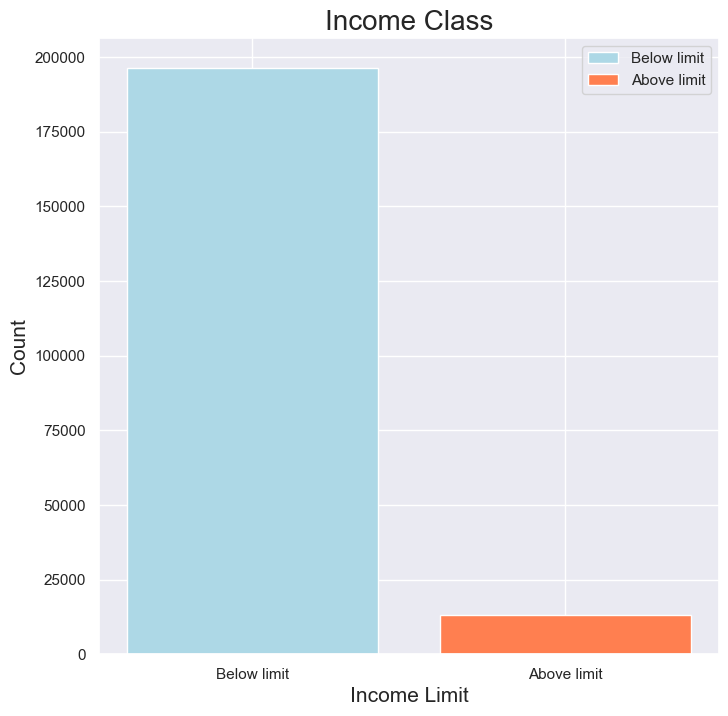

In [51]:
x = df['income_above_limit'].unique()
y = df['income_above_limit'].value_counts()
print(df.groupby('income_above_limit')['income_above_limit'].value_counts())

plt.figure(figsize=(8,8))
sns.set(style='darkgrid')

plt.bar(x,y,color=["lightblue", "coral"],data=df,label=['Below limit','Above limit'])
plt.title('Income Class',fontsize=20)
plt.xlabel('Income Limit',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.legend(loc=1)
plt.show()

### This Plot shows the number of Upper and Lower Limits in Women and the number of Upper and Lower Limits in Men.

gender  income_above_limit
Female  Below limit           105996
        Above limit             2788
Male    Below limit            90505
        Above limit            10210
Name: count, dtype: int64


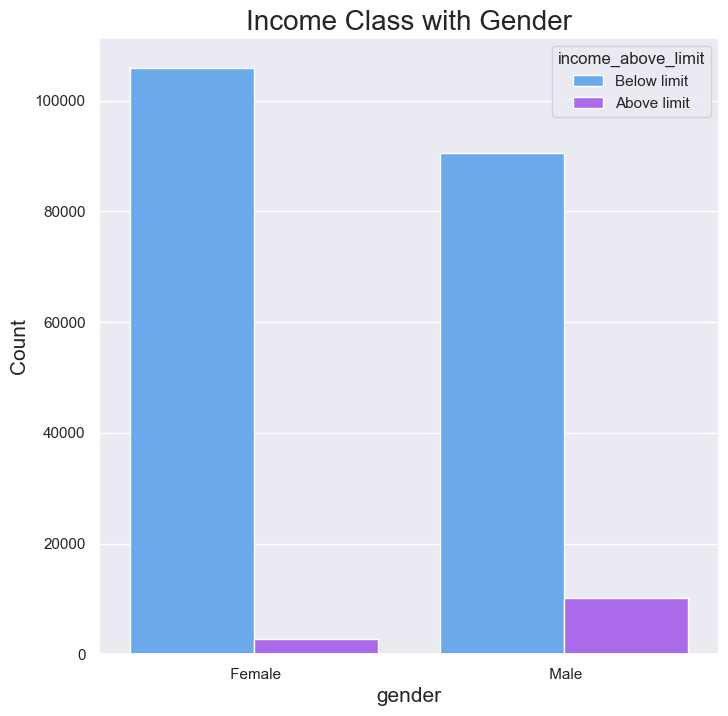

In [52]:
gender = df.groupby('gender')['income_above_limit'].value_counts()
print(gender)
plt.figure(figsize=(8,8))
sns.countplot(x='gender',data=df,hue='income_above_limit',palette='cool')
plt.title('Income Class with Gender',fontsize=20)
plt.xlabel('gender',fontsize=15)
plt.ylabel('Count',fontsize=15)

plt.show()

### This Plot shows the number of Upper and Lower Limits in Married and the number of Upper and Lower Limits in Unmarried.

marital_status                   income_above_limit
Divorced                         Below limit           12361
                                 Above limit            1095
Married-A F spouse present       Below limit             707
                                 Above limit              13
Married-civilian spouse present  Below limit           78313
                                 Above limit           10094
Married-spouse absent            Below limit            1464
                                 Above limit             104
Never married                    Below limit           89553
                                 Above limit            1170
Separated                        Below limit            3439
                                 Above limit             157
Widowed                          Below limit           10664
                                 Above limit             365
Name: count, dtype: int64


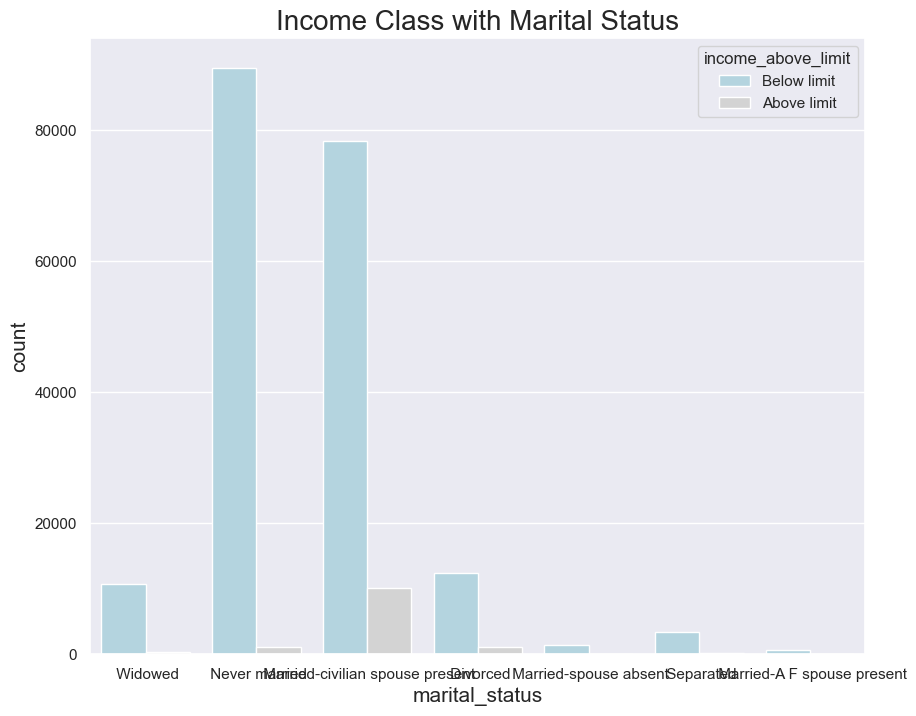

In [53]:
marr= df.groupby('marital_status')['income_above_limit'].value_counts()
print(marr)
plt.figure(figsize=(10,8))

sns.countplot(x='marital_status',hue='income_above_limit',data=df,palette=['lightblue', 'lightgrey'])
plt.title('Income Class with Marital Status',fontsize=20)
plt.xlabel('marital_status',fontsize=15)
plt.ylabel('count',fontsize=15)
plt.show()

### This plot shows the percentage of Above limit and Below limit of the column containing incom_above_limit.
### This plot shows the percentage of male and female of the column containing gender.
### This plot shows the percentage of married and single of the column containing marital_status.

income_above_limit
Above limit     12998
Below limit    196501
Name: count, dtype: int64
gender
Female    108784
Male      100715
Name: count, dtype: int64
marital_status
Divorced                           13456
Married-A F spouse present           720
Married-civilian spouse present    88407
Married-spouse absent               1568
Never married                      90723
Separated                           3596
Widowed                            11029
Name: count, dtype: int64


ValueError: 'explode' must be of length 'x', not 2

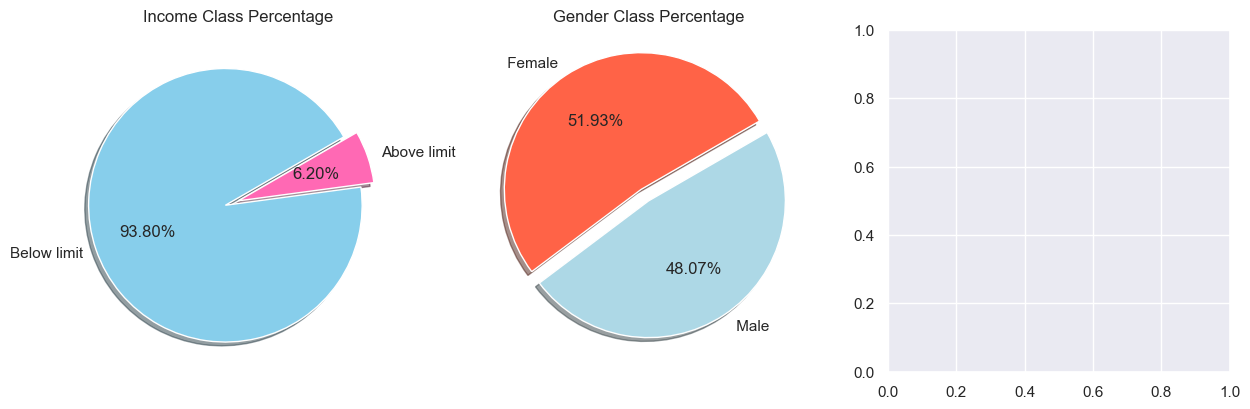

In [54]:

plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
income = df['income_above_limit'].unique()
income_val = df['income_above_limit'].value_counts()
print(df.groupby('income_above_limit')['income_above_limit'].value_counts())
e = [0.10,0]
plt.pie(income_val,labels=income,explode=e,autopct='%0.2f%%',shadow=True,startangle=30,colors=['SkyBlue','HotPink'])
plt.title('Income Class Percentage')

plt.subplot(1,3,2)
gender = df['gender'].unique()
gender_val = df['gender'].value_counts()
print(df.groupby('gender')['gender'].value_counts())
e = [0.10,0]
plt.pie(gender_val,labels=gender,explode=e,autopct='%0.2f%%',shadow=True,startangle=30,colors=['Tomato','lightblue'])
plt.title('Gender Class Percentage')

plt.subplot(1,3,3)
marriad = df['marital_status'].unique()
marriad_val = df['marital_status'].value_counts()
print(df.groupby('marital_status')['marital_status'].value_counts())
e = [0.10,0]
plt.pie(marriad_val,labels=marriad,explode=e,autopct='%0.2f%%',shadow=True,startangle=30,colors=['lightgrey','orange'])
plt.title('Marital Status Percentage')



plt.show()

### This plot shows the values of the education column in terms of courses.

education
High school graduate                      50627
Children                                  49685
Some college but no degree                29320
Bachelors degree(BA AB BS)                20979
7th and 8th grade                          8438
10th grade                                 7905
11th grade                                 7260
Masters degree(MA MS MEng MEd MSW MBA)     6861
9th grade                                  6540
Associates degree-occup /vocational        5650
Associates degree-academic program         4494
5th or 6th grade                           3542
12th grade no diploma                      2282
1st 2nd 3rd or 4th grade                   1917
Prof school degree (MD DDS DVM LLB JD)     1852
Doctorate degree(PhD EdD)                  1318
Less than 1st grade                         829
Name: count, dtype: int64


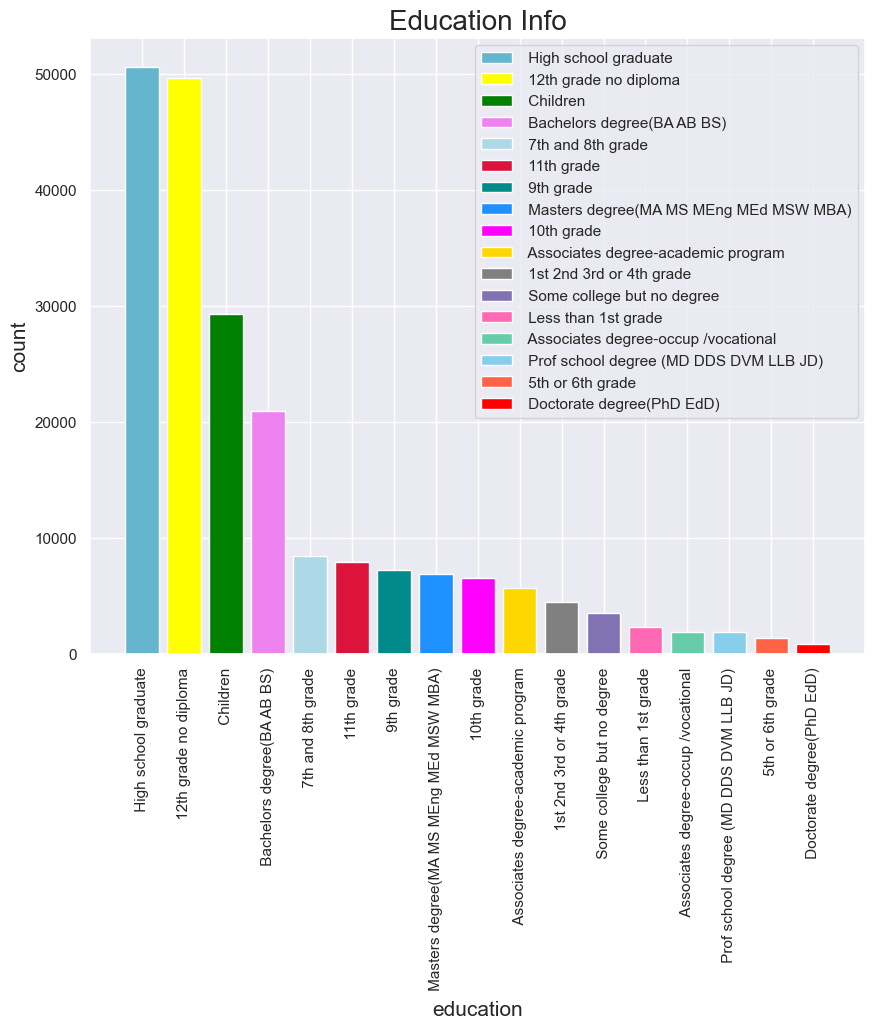

In [55]:
x = df['education'].unique()
y = df['education'].value_counts()
print(y)
col =['c','yellow','green','violet','lightblue','Crimson','DarkCyan','DodgerBlue','Fuchsia','gold','grey','m','HotPink','MediumAquaMarine','SkyBlue','Tomato','red']
plt.figure(figsize=(10,8))
plt.bar(x,y,label=x,color=col,data=df)
plt.title('Education Info',fontsize=20)
plt.xlabel('education',fontsize=15)
plt.ylabel('count',fontsize=15)
plt.xticks(rotation=90)
plt.legend(loc=1)
plt.show()

### This plot shows the average age of female and male with of education.

In [56]:
df.groupby(['education','gender'])['age'].mean()

education                               gender
10th grade                              Female    39.950333
                                        Male      36.775764
11th grade                              Female    36.905983
                                        Male      34.283613
12th grade no diploma                   Female    40.109221
                                        Male      36.650644
1st 2nd 3rd or 4th grade                Female    58.438819
                                        Male      55.090815
5th or 6th grade                        Female    54.694072
                                        Male      50.636830
7th and 8th grade                       Female    54.674051
                                        Male      49.369457
9th grade                               Female    37.221865
                                        Male      33.114460
Associates degree-academic program      Female    41.042667
                                        Male      41.

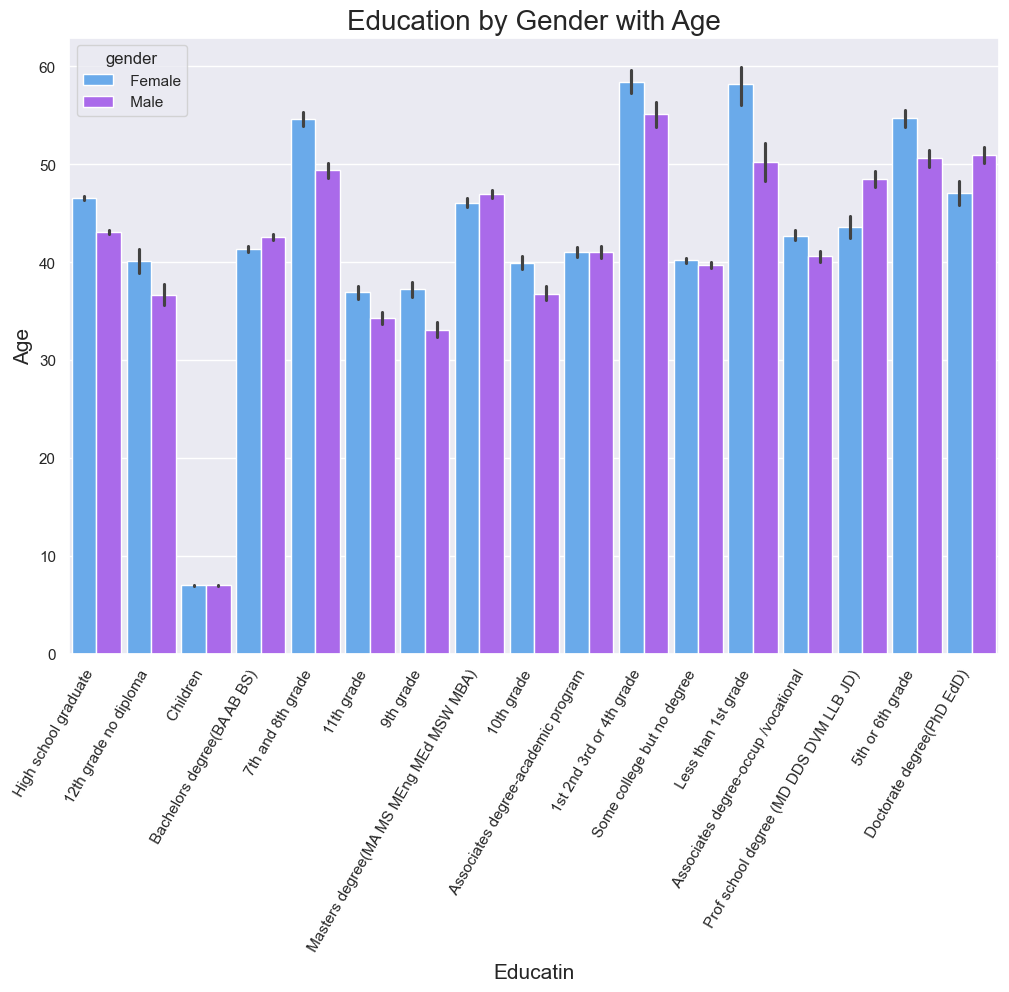

In [57]:

plt.figure(figsize=(12,8))
sns.barplot(x='education',y='age',data=df,hue='gender',width=0.9,palette='cool')
plt.xlabel('Educatin',fontsize=15)
plt.ylabel('Age',fontsize=15)
plt.title('Education by Gender with Age',fontsize=20)
plt.xticks(rotation=60,ha='right')
plt.show()

### This both different via plot shows the number of married and single males and the mean of married and single females.

In [ ]:
age_mean = df.groupby(['gender','marital_status'])['age'].mean()
print(age_mean)
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.barplot(x='gender',y='age',hue='marital_status',data=df,palette="hot",estimator='mean',capsize=0.1,errorbar=('ci', 100))
plt.title('marital_status',fontsize=20)

plt.subplot(1,2,2)
plt.title('marital_status',fontsize=20)
sns.boxplot(x='gender',y='age',hue='marital_status',data=df,palette="plasma",orient='vertical')
plt.show()

### This plot shows the average of female and male with the values of employment_commitment.

In [ ]:
x = df['employment_commitment'].unique()
y = df['employment_commitment'].value_counts()

print(df.groupby(['employment_commitment','gender'])['age'].mean())
plt.figure(figsize=(12,8))

sns.barplot(x='employment_commitment',y='age',hue='gender',data=df,palette=['lightblue','Tomato'])
plt.title('employment_commitment',fontsize=20)
plt.xlabel('employment_commitment',fontsize=15)
plt.ylabel('age',fontsize=15)
plt.xticks(rotation=60,ha='right')
plt.show()


### This plot show the number based on the continued values of the age.

In [ ]:
print('Minimum Age is ',df['age'].min())
print('Maximum Age is ',df['age'].max())
print('Mean Age is ',df['age'].mean())

plt.figure(figsize=(10,6))

sns.histplot(df['age'],binwidth=5,kde=True)
plt.title('Age Count',fontsize=20)
plt.xlabel('Age',fontsize=13)
plt.ylabel('count',fontsize=13)
plt.xticks(np.arange(0,91,5))
# plt.bar_label(patches, labels=[str(int(v)) for v in n], padding=3, fontsize=10)
plt.show()

### This plot shows that the shows age according to old_residence_state based on male and female.

In [ ]:
state = df.groupby(['old_residence_reg','gender'])['age'].mean()
print(state)

In [ ]:

x = df['old_residence_reg'].unique()
y = df['old_residence_reg'].value_counts()

plt.figure(figsize=(20,8))

sns.barplot(x='old_residence_reg',y='age',hue='gender',data=df,palette='plasma')
plt.title('old_residence_reg with gender and age',fontsize=20)
plt.xlabel('old_residence_reg',fontsize=15)
plt.ylabel('age',fontsize=15)
plt.xticks(rotation=90)

plt.show()

### This plot shows how many importance records there are by age, based on the above limit and below limit, for males and females.

In [ ]:
pd.set_option('display.max_rows', None)
record = df.groupby(['age','gender','income_above_limit'])['importance_of_record'].sum()
print(record)

In [ ]:


plt.figure(figsize=(17,10))

sns.scatterplot(x='age',y='importance_of_record',hue='income_above_limit',style='gender',data=df, size='importance_of_record', sizes=(40, 400),alpha=0.8)
plt.xticks(np.arange(0,91,5))
plt.yticks(np.arange(0,20001,2000))
plt.title('Income_Above_Limit with Age And Gender',fontsize = 20)
plt.xlabel('age',fontsize = 15)
plt.ylabel('importance_of_record',fontsize = 15)

plt.show()


In [ ]:
# Create count plot
ax = sns.barplot(x='marital_status',y='age', data=df, hue='marital_status')

# Rotate x-axis labels
plt.xticks(rotation=90)

# Add bar labels
for bars in ax.containers:
    ax.bar_label(bars)

# Show plot
plt.show()

In [ ]:
df1 = df

In [ ]:
df1[df1['age']==47]

# Data Feature Engineering

## Replace Value for Income Above Limit or Belowe Limit

In [ ]:
df = df.rename(columns={'class': 'class_of_worker'})

## Replace Limit in 0 or 1

In [ ]:
df['income_above_limit'].replace({'Below limit':0,'Above limit':1},inplace=True)

In [ ]:
pd.set_option('display.max_columns', None)
df.head(2)

## LabelEncoder

In [ ]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [ ]:
le = LabelEncoder()

for i in cat_cols:
    df[i] = le.fit_transform(df[i])

In [ ]:
X = df.drop(columns=['income_above_limit','ID','employment_stat','is_hispanic','industry_code','occupation_code'], axis=1)
Y = df['income_above_limit']

In [ ]:
X.head()

## train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=25)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

In [ ]:
X_train.head()

## RandomUnderSampler

In [ ]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler()
# X_resampled, y_resampled = rus.fit_resample(X_train, Y_train)

## StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_sts = scaler.fit_transform(X_train)
X_test_sts = scaler.transform(X_test)

# Model

## LogisticRegression

In [ ]:
regression = LogisticRegression()
regression.fit(X_train_sts, Y_train)

In [ ]:
Y_pred_logi = regression.predict(X_test_sts)
Y_pred_logi

In [ ]:
accuracy = accuracy_score(Y_test,Y_pred_logi)
classi_report = classification_report(Y_test, Y_pred_logi)
cm = confusion_matrix(Y_test, Y_pred_logi)

print("accuracy_score : ",accuracy)
print("classification_report : ",classi_report)
print("Confusion Matrix : ",cm)

In [ ]:
print(regression.predict(scaler.transform([[79,0,12,3,0,0,2,3,0,52,14,0,2,20,4,0,2,0,0,0,292,1,95,39,1,3,1779.74]])))
print(regression.predict(scaler.transform([[47,1,9,1,0,0,0,3,0,37,5,9,4,37,7,0,2,2,0,0,440,1,94,39,1,3,1283.03]])))

## DecisionTreeClassifier

In [ ]:
d_classifier = DecisionTreeClassifier(criterion='gini',random_state=35)
d_classifier.fit(X_train_sts, Y_train)

In [ ]:
Y_pred_dtree = d_classifier.predict(X_test_sts)
Y_pred_dtree

In [ ]:
accuracy = accuracy_score(Y_test,Y_pred_dtree)
classi_report = classification_report(Y_test, Y_pred_dtree)
cm = confusion_matrix(Y_test, Y_pred_dtree)

print("accuracy_score : ",accuracy)
print("classification_report : ",classi_report)
print("Confusion Matrix : ",cm)

In [ ]:
print(d_classifier.predict(scaler.transform([[79,0,12,3,0,0,2,3,0,52,14,0,2,20,4,0,2,0,0,0,292,1,95,39,1,3,1779.74]])))
print(d_classifier.predict(scaler.transform([[47,1,9,1,0,0,0,3,0,37,5,9,4,37,7,0,2,2,0,0,440,1,94,39,1,3,1283]])))
# print(d_classifier.predict(scaler.transform([[]])))

## RandomForestClassifier

In [ ]:
r_model = RandomForestClassifier(n_estimators = 400, criterion = 'entropy',random_state=42)
r_model.fit(X_train_sts, Y_train)

In [ ]:
Y_pred_rfc = r_model.predict(X_test_sts)
Y_pred_rfc

In [ ]:
accuracy = accuracy_score(Y_test,Y_pred_rfc)
classi_report = classification_report(Y_test, Y_pred_rfc)
cm = confusion_matrix(Y_test, Y_pred_rfc)

print("accuracy_score : ",accuracy)
print("classification_report : ",classi_report)
print("Confusion Matrix : ",cm)

In [ ]:
print(r_model.predict(scaler.transform([[79,0,12,3,0,0,2,3,0,52,14,0,2,20,4,0,2,0,0,0,292,1,95,39,1,3,1779.74]])))
print(r_model.predict(scaler.transform([[47,1,9,1,0,0,0,3,0,37,5,9,4,37,7,0,2,2,0,0,440,1,94,39,1,3,1283]])))

## KNeighborsClassifier

In [ ]:
k_classifier = KNeighborsClassifier(n_neighbors = 42, metric = 'minkowski', p = 2)
k_classifier.fit(X_train_sts, Y_train)

In [ ]:
Y_pred_knc = k_classifier.predict(X_test_sts)
Y_pred_knc

In [ ]:
print(k_classifier.predict(scaler.transform([[79,0,12,3,0,0,2,3,0,52,14,0,2,20,4,0,2,0,0,0,292,1,95,39,1,3,1779.74]])))
print(k_classifier.predict(scaler.transform([[47,1,9,1,0,0,0,3,0,37,5,9,4,37,7,0,2,2,0,0,440,1,94,39,1,3,1283]])))

## SVC

In [ ]:
# s_classifier = SVC()
# s_classifier.fit(X_train_sts, Y_train)

In [ ]:
# Y_pred = s_classifier.predict(X_test_sts)
# accuracy_score(Y_test,Y_pred)

In [ ]:
# print(s_classifier.predict(scaler.transform([[79,0,12,3,0,0,2,3,0,0,52,14,0,2,20,4,0,2,0,0,0,292,1,95,39,1,3,1779.74]])))
# print(s_classifier.predict(scaler.transform([[47,1,9,1,0,0,0,3,0,0,37,5,9,4,37,7,0,2,2,0,0,440,1,94,39,1,3,1283]])))

In [ ]:
with open('rendam_model.pkl', 'wb') as file:
    pickle.dump(r_model, file)

In [ ]:
with open('randam_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)